<a href="https://colab.research.google.com/github/tariqeman727-ui/-Code-Alpha-internship-Task-01/blob/main/CodeAlpha_Internship_Task_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Install and import libraries.



In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

#Load Dataset (MNIST)

In [2]:
mnist = keras.datasets.mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#Check Datashape

In [3]:
print(X_train.shape)
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


#Show sample images.



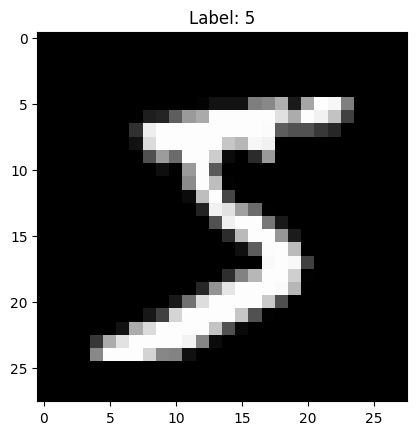

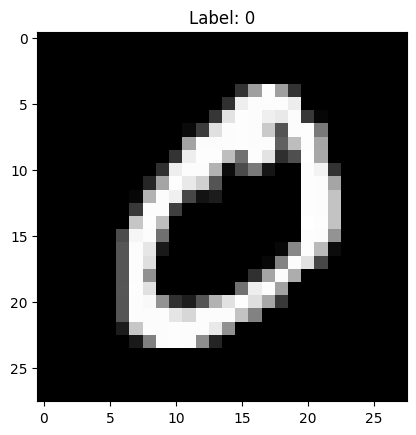

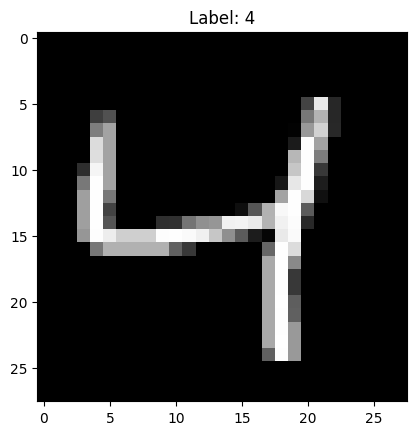

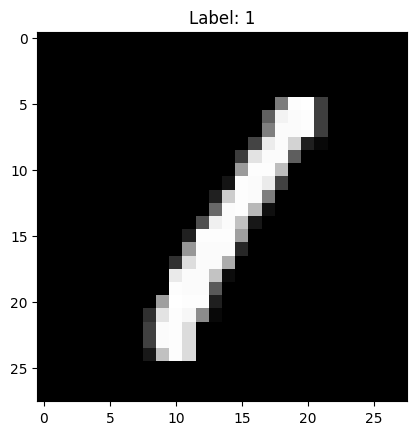

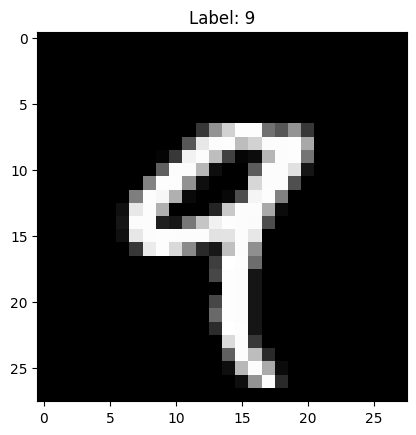

In [4]:
for i in range(5):
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.show()

#Normalise data.




In [5]:
X_train = X_train / 255.0
X_test = X_test / 255.0

#Reshape for Cnn.

In [6]:
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

#Build Cnn model.

In [7]:
model = keras.models.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#Compile model.

In [8]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

#Train model.

In [9]:
history = model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 32ms/step - accuracy: 0.9623 - loss: 0.1270 - val_accuracy: 0.9865 - val_loss: 0.0433
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 32ms/step - accuracy: 0.9872 - loss: 0.0415 - val_accuracy: 0.9881 - val_loss: 0.0348
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.9911 - loss: 0.0288 - val_accuracy: 0.9927 - val_loss: 0.0239
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 30ms/step - accuracy: 0.9936 - loss: 0.0200 - val_accuracy: 0.9887 - val_loss: 0.0356
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 31ms/step - accuracy: 0.9955 - loss: 0.0142 - val_accuracy: 0.9901 - val_loss: 0.0346


#Evaluate model.

In [10]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9901 - loss: 0.0346
Test Accuracy: 0.9901000261306763


#Confusion Matrix.

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step


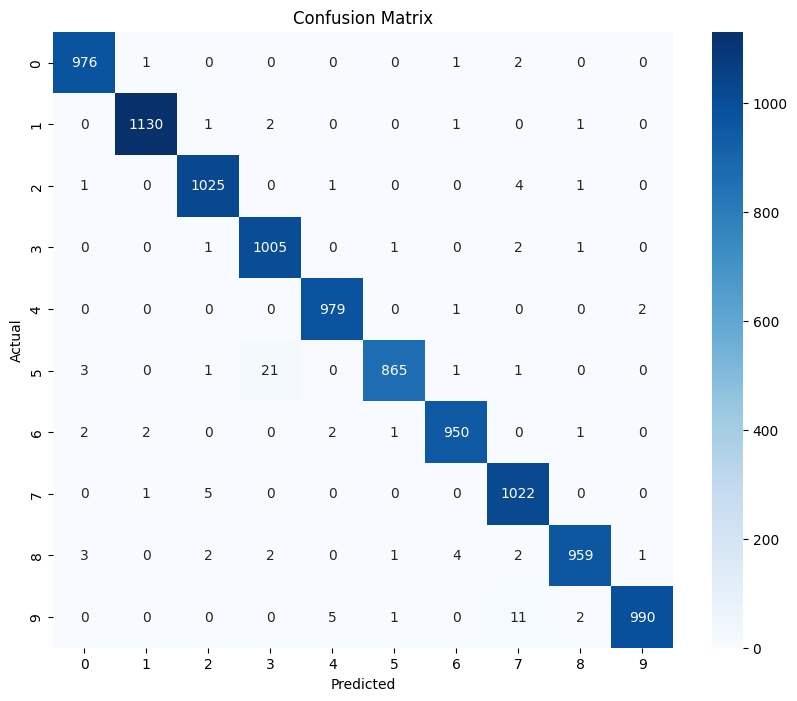

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = np.argmax(model.predict(X_test), axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#Plot accuracy graph.

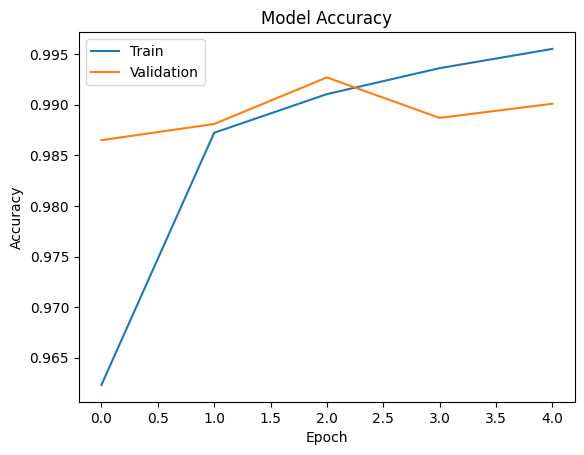

In [12]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

#Make Prediction.

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


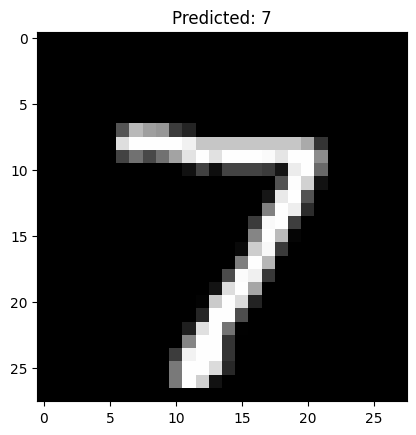

In [13]:
predictions = model.predict(X_test)

plt.imshow(X_test[0].reshape(28,28), cmap='gray')
plt.title(f"Predicted: {np.argmax(predictions[0])}")
plt.show()

#Analysis Report


Task 1: Handwritten Digit Recognition — Explanation

The Convolutional Neural Network (CNN) model was trained on the MNIST dataset, which contains 60,000 training images and 10,000 testing images of handwritten digits (0–9).

After training for 5 epochs, the model achieved:

Training/Test Accuracy: 0.9901 (~99%)

Test Loss: 0.0346

This high accuracy indicates that the model learned the patterns of handwritten digits very well. Most predictions are correct, and misclassifications are very few. The model was further evaluated using a confusion matrix, which confirmed its reliable performance across all digit classes.

Reason for high accuracy:

MNIST is a clean and simple dataset.

CNN is effective at extracting features from images.

Large number of training images (60,000) helped the model generalize well.

Proper preprocessing (normalization) improved learning efficiency.

Conclusion:
The CNN model successfully recognizes handwritten digits with ~99% accuracy, demonstrating the effectiveness of deep learning in image classification.